---
title: "Convolutional Neural Networks (Part 1)"
short_title: Part 1
subject: DEEP LEARNING
---

## Introduction

Fully-connected neural networks (FCNs) are highly flexible, but their lack of priors makes them inefficient for many tasks, particularly those involving structured data such as images or audio. **Convolutional Neural Networks** (CNNs) address this limitation of FCNs by incorporating incorporating an architectural design that is aligned with the inherent properties of grid-structured data. By focusing on local dependencies and leveraging parameter sharing, CNNs efficiently capture spatial or temporal patterns while remaining computationally scalable.


CNNs contain **convolutional layers** which extract spatially invariant features by sliding learnable filters across the input. These layers hierarchically compose simple patterns (edges, textures) into complex representations (shapes, objects). This compositionality &mdash; paired with **weight sharing** and **pooling** &mdash; allows CNNs to generalize remarkably well even with limited data[^data]. Finally, we perform **transfer learning** to fine-tune a [pretrained vision model](https://pytorch.org/vision/main/models.html) on a specialized task.

[^data]: Data augmentation techniques naturally apply to images.

:::{figure} ./img/03-lenet.png
---
align: center
name: 03-lenet
---
**LeNet-5 architecture** (1989). [**Source**](https://www.d2l.ai/chapter_convolutional-neural-networks/lenet.html)
:::

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = "svg"
from tqdm import tqdm
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import torch
import torch.nn as nn
import torch.nn.functional as F

import random
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

ROOT_DIR = Path("../../").resolve()
LOCAL_DIR = ROOT_DIR / ".local/"
DATASET_DIR = LOCAL_DIR / "data/"
ARTIFACTS_DIR = LOCAL_DIR / "artifacts/"
warnings.simplefilter(action="ignore")
matplotlib.rcParams["image.interpolation"] = "nearest"

RANDOM_SEED = 0
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

def get_device(): 
    return (
        torch.device("cuda:0") if torch.cuda.is_available() else (
            torch.device("mps") if torch.mps.is_available() else 
                torch.device("cpu")
        )
    )

DEVICE = get_device()
print(f"Using device: {DEVICE}")

Using device: mps


## Convolution operation

Suppose we want to classify images using a linear model. Flattening the image into a vector 
and feeding it into a fully-connected network, it turns out, is not a good approach.
The large flattened input vector requires a very large weight matrix.
Moreover, it does not consider spatial correlation of nearby pixels ({numref}`cat-conv`)
(e.g. applying a fixed permutation to input data results in an equivalent network).
This motivates constraining the operation so that only nearby pixels are mixed via a linear combination, resulting in a very sparse banded weight matrix ({numref}`toeplitz`).

:::{figure} ./img/03-cat.png
---
width: 400px
align: center
name: cat-conv
---
**Locality in images.**
Nearby pixels combine to form meaningful features of an image. [Source](https://www.nationalgeographic.com/animals/mammals/facts/domestic-cat)
:::

Let $\boldsymbol{\mathsf X}$ be an $n \times n$ input image and $\boldsymbol{\mathsf{S}}$ be the $m \times m$ output feature map. The banded weight matrix reduces the nonzero entries of the weight matrix from $m^2 n^2$ to $m^2{k}^2$ where a local region of $k \times k$ pixels in the input image are mixed. If the feature detector is translationally invariant across the image,
then the weights in each band are **shared**. This further reduces the number of weights to $O(k^2).$
The resulting linear operation is called a **convolution** in two spatial dimensions:


$$
\boldsymbol{\mathsf{S}}_{ij} = (\boldsymbol{\mathsf X} \circledast \boldsymbol{\mathsf{K}})_{ij} = \sum_{x = 0}^{{k}-1} \sum_{y=0}^{{k}-1} {\boldsymbol{\mathsf X}}_{i + x, j + y} \, {\boldsymbol{\mathsf{K}}}_{xy}.
$$


Observe that spatial ordering of the pixels in the input $\boldsymbol{\mathsf X}$ is preserved in the output $\boldsymbol{\mathsf{S}}.$ This is nice since we want spatial information and orientation across a stack of convolution operations to be passed down into the final output.

:::{figure} ./img/03-conv-cat-99.png
---
width: 600px
align: center
name: toeplitz
---
**Banded Toeplitz matrix for classifying images** The horizontal vectors contain the same pixel values. Note that there can be multiple bands for a 2D kernel. See this [SO answer](https://stackoverflow.com/a/44039201/1091950) for further discussion. [[Source]](https://deepimaging.github.io/lectures/lecture_9_intro_to_CNN's.pdf).
:::

**Remark.** It can be shown that convolution has [translation equivariance](https://en.wikipedia.org/wiki/Equivariant_map) due to weight sharing. 

```{figure} ./img/03-cnn-weight-sharing.png
---
width: 800px
align: center
name: 03-cnn-weight-sharing
---
Having local neural connectivity and weight sharing (both kernel and bias weights) characterizes the convolution. [Source](https://maurice-weiler.gitlab.io/blog_post/cnn-book_2_conventional_cnns/)
```

## Convolution layer

The **convolution layer** extends the convolution operation to handle input with [multiple channels](https://en.wikipedia.org/wiki/Channel_(digital_image)). The output similarly has channels adding a further semantic dimension to the downstream representation. For an RGB image, a convolution layer learns three 2-dimensional kernels $\boldsymbol{\mathsf{K}}_{lc}$ for each output channel, each of which can be thought of as a **feature extractor**. Features across input channels are blended by the kernel:

$$
\begin{aligned}
{\bar{\boldsymbol{\mathsf X}}}_{lij}
&= {\boldsymbol{\mathsf u}}_{l} + \sum_{c=0}^{{c}_\text{in}-1} ({\boldsymbol{\mathsf X}}_{[c,\,:,\, :]} \circledast {\boldsymbol{\mathsf K}}_{[l,\,{c},\, :,\,:]})_{ij} \\
&= {\boldsymbol{\mathsf u}}_{l} + \sum_{c=0}^{{c}_\text{in}-1}\sum_{x = 0}^{{k}-1} \sum_{y=0}^{{k}-1} {\boldsymbol{\mathsf X}}_{c,\, i + x,\, j + y} \, {\boldsymbol{\mathsf K}}_{lcxy} \\
\end{aligned}
$$

for $l = 0, \ldots, {c}_\text{out}-1$. The input and output tensors $\boldsymbol{\mathsf{X}}$ and $\bar{\boldsymbol{\mathsf{X}}}$ have the same dimensionality and semantic structure which makes sense since we want to stack convolutional layers as modules, and the kernel $\boldsymbol{\mathsf{K}}$ has shape $({c}_\text{out}, {c}_\text{in}, {k}, {k}).$ The resulting feature maps inherit the spatial ordering in its inputs along the spatial dimensions. The entire operation is linear and each convolution operation is independent for each output channel. 


### Input and output channels

Reproducing the convolution operation over input and output channels:

In [3]:
def convolve(X, K):
    """Perform 2D convolution over input."""
    h, w = K.shape
    H0, W0 = X.shape
    H1 = H0 - h + 1
    W1 = W0 - w + 1

    S = np.zeros(shape=(H1, W1))
    for i in range(H1):
        for j in range(W1):
            S[i, j] = (X[i:i+h, j:j+w] * K).sum()
    
    return torch.tensor(S)

Decomposing the feature maps:

In [4]:
from torchvision.io import read_image
import torchvision.transforms.functional as fn

@torch.no_grad()
def conv_components(X, K, u):
    cmaps = ["Reds", "Greens", "Blues"]
    cmaps_out = ["spring", "summer", "autumn", "winter"]
    c_in  = X.shape[1]
    c_out = K.shape[0]
    
    fig, ax = plt.subplots(c_in + 1, c_out + 1, figsize=(10, 10))

    # Input image
    ax[0, 0].imshow(X[0].permute(1, 2, 0))
    for c in range(c_in):
        ax[c+1, 0].set_title(f"X(c={c})", size=10)
        ax[c+1, 0].imshow(X[0, c, :, :], cmap=cmaps[c])

    # Iterate over kernel filters
    out_components = {}
    for k in range(c_out):
        for c in range(c_in):
            out_components[(c, k)] = convolve(X[0, c, :, :], K[k, c, :, :])
            ax[c+1, k+1].imshow(out_components[(c, k)].numpy()) 
            ax[c+1, k+1].set_title(f"X(c={c}) ⊛ K(c={c}, k={k})", size=10)

    # Sum convolutions over input channels, then add bias
    out_maps = []
    for k in range(c_out):
        out_maps.append(sum([out_components[(c, k)] for c in range(c_in)]) + u[k])
        ax[0, k+1].imshow(out_maps[k].numpy(), cmaps_out[k])
        ax[0, k+1].set_title(r"$\bar{\mathrm{X}}$" + f"(k={k})", size=10)

    fig.tight_layout()
    return out_maps


cat = DATASET_DIR / "shorty.png"
X = read_image(str(cat)).unsqueeze(0)[:, :3, :, :]
X = fn.resize(X, size=(128, 128)) / 255.
conv = nn.Conv2d(in_channels=3, out_channels=4, kernel_size=5)
K, u = conv.weight, conv.bias
components = conv_components(X, K, u)

plt.savefig("./plots/03-conv_components.svg", bbox_inches="tight")
plt.close("all")

:::{figure} ./plots/03-conv_components.svg
---
name: 03-conv_components
width: 100%
align: center
---
**Decomposing convolution terms.** Each kernel in entries `i,j > 0` combines column-wise with the inputs to compute `X(c=i) ⊛ K(c=i, k=j)`. The sum of these terms over `c` form the output map `X̅(k=j)` above. 
This looks like computation in a fully-connected layer, but with convolutions between matrices instead of products between scalars. This is consistent with the idea that CNNs perform combinatorial mixing of hierarchical spatial features with depth.
:::


Checking if the output of `conv_components` is consistent with `Conv2d` in PyTorch:

In [5]:
S = torch.stack(components).unsqueeze(0)
P = conv(X)
cmaps_out = ["spring", "summer", "autumn", "winter"]

print("Input shape: ", X.shape)   # (B, c0, H0, W0)
print("Output shape:", S.shape)   # (B, c1, H1, W1)
print("Kernel shape:", K.shape)   # (c1, c0, h, w)
print("Bias shape:  ", u.shape)   # (c1,)
print()
print(f"MAE (w/ pytorch) = {(S - P).abs().mean().item():.3e}")

Input shape:  torch.Size([1, 3, 128, 128])
Output shape: torch.Size([1, 4, 124, 124])
Kernel shape: torch.Size([4, 3, 5, 5])
Bias shape:   torch.Size([4])

MAE (w/ pytorch) = 2.400e-08


### Padding and stride

The step size of the kernel can be controlled using the **stride** parameter. A large stride along with a large kernel size can be useful if objects are large relative to the dimension of the image. Note that strided convolutions can be used as an alternative way to downsample an image (where it is shown to work better or just as well as the usual conv + pooling layers for certain benchmark tasks) {cite:p}`allconv`. Hence, stride significantly reduces computation of the layer (i.e. by the same factor). For example, `stride=2` divides the spatial size of the original image by 2:

In [6]:
conv = lambda s: nn.Conv2d(3, 1, stride=s, kernel_size=3)

In [7]:
fig, ax = plt.subplots(1, 4, figsize=(8, 2))
ax[0].imshow(X[0].permute(1, 2, 0))
ax[1].imshow(conv(1)(X)[0, 0].detach().numpy()); ax[1].set_title("s=1")
ax[2].imshow(conv(4)(X)[0, 0].detach().numpy()); ax[2].set_title("s=4")
ax[3].imshow(conv(8)(X)[0, 0].detach().numpy()); ax[3].set_title("s=8")
for i in range(4):
    ax[i].tick_params(axis="both", which="major", labelsize=8)
    
fig.tight_layout()
plt.savefig("./plots/03-conv_stride.svg", bbox_inches="tight")
plt.close("all")


:::{figure} ./plots/03-conv_stride.svg
---
name: 03-conv_stride
width: 100%
align: center
---
**Strided convolution.** Higher stride downsamples an input more.
:::

**Padding.** Edge pixels of an input image are underrepresented since the kernel has to be kept within the input image. Moreover, information in the edges become lost as we stack more convolutional layers. The simplest idea is **zero padding** the boundaries (more involved variants exist). Observe the weird effect it has on the boundaries:

In [17]:
pad  = nn.ZeroPad2d(padding=5)
conv = nn.Conv2d(3, 1, kernel_size=10)

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(4, 4))
vmin = min(conv(X).min(), conv(pad(X)).min())
vmax = max(conv(X).max(), conv(pad(X)).max())
ax[1, 0].imshow(pad(X)[0].permute(1, 2, 0).detach(), vmin=vmin, vmax=vmax); ax[1, 0].set_title("pad(X)", fontsize=10)
ax[1, 1].imshow(conv(pad(X))[0, 0].detach(),         vmin=vmin, vmax=vmax); ax[1, 1].set_title("conv(pad(X))", fontsize=10)
ax[0, 0].imshow(X[0].permute(1, 2, 0).detach(),      vmin=vmin, vmax=vmax); ax[0, 0].set_title("X", fontsize=10)
ax[0, 1].imshow(conv(X)[0, 0].detach(),              vmin=vmin, vmax=vmax); ax[0, 1].set_title("conv(X)", fontsize=10)
ax[0, 0].tick_params(axis="both", which="major", labelsize=8)
ax[0, 1].tick_params(axis="both", which="major", labelsize=8)
ax[1, 0].tick_params(axis="both", which="major", labelsize=8)
ax[1, 1].tick_params(axis="both", which="major", labelsize=8)
fig.tight_layout()
plt.savefig("./plots/03-conv_padding.svg", bbox_inches="tight")
plt.close("all")

:::{figure} ./plots/03-conv_padding.svg
---
name: 03-conv_padding
width: 400px
align: center
---
**Padding convolution inputs.** Padding allows same sized input and output images. However, observe that padding has a weird effect on boundary.
:::

**Remark.** Padding and stride determine the output shape. A convolution layer with kernel size $k$ and stride $s$ applied to an input of width $w$ with symmetric padding $p$, results in an output width of $\left\lfloor \frac{w + 2p - k}{s} + 1 \right\rfloor$. In general, we want to pick stride and padding values so that the kernel can be placed evenly in the image with no input pixel dropped.

For $s = 1$, the kernel size should be odd so that it covers the entire input in a symmetric manner. A common choice is $p = \frac{1}{2}(k - 1)$ which results in same sized outputs[^1] (**same convolution**). For $s > 1$, best practice is to choose a kernel size and the smallest $p$ such that $s$ divides $w + 2p - k$ so that the entire input image is symmetrically covered by the kernel.

[^1]: The kernel $p$ pixels on the left side of a kernel at the start, and $p$ on the right at the other end, where $p = \frac{1}{2}(k - 1)$ and the kernel is centered on the central pixel (i.e. the $-1$).

## Pooling layers

Pooling layers downsample an input by performing nonparametric operations that slide across the input like convolutional layers. This effectively decreases the resolution of feature maps (much like zooming out) that subsequent layers will work on. Pooling is applied to each channel separately, so that the number of channels is maintained. This makes sense since we want only to compress the input spatially without modifying its semantic structure.

```{figure} ./img/03-pooling-cs231n.png
---
width: 350px
align: center
---

**Downsampling by pooling.** Pooling layer downsamples the volume spatially independently in each channel. The input tensor of size 224 × 224 × 64 is pooled with filter size 2 and stride 2 into output volume of size 112 × 112 × 64. [Source](https://cs231n.github.io/convolutional-networks/)
```

The **receptive field** of a unit is the union of all units that influence its value during forward pass ({numref}`receptive_field`). In particular, units corresponding to each class label should ideally have a receptive field that includes the entire (or at least almost all) input pixels. Otherwise the network will have blind spots in its input. A way to exponentially increase receptive field, and also make the network more robust to noise, is by **downsampling**. Here we do it along the spatial dimensions.


```{figure} ./img/03-receptive_field.png
---
name: receptive_field
width: 500px
align: center
---
**Receptive field of a pixel in a convolutional network.** For an output pixel in an intermediate layer, whose are inputs are formed from stacked convolutions, its larger receptive field indicates that it processes hierarchical features of the original image. (Fig 14.2 in {cite:p}`geron2019hands-on`.)
```

### Max pooling

Max pooling makes the network insensitive to noise or fine-grained details in the input at the cost of some potential signal loss. It can also be interpreted as competition between neurons since the gradient only flows through the maximally activated neuron. A soft alternative is **average pooling**. Some  natural choices of parameters are `kernel=2,stride=2` where pooling regions do not overlap, and `kernel=3,stride=2` where some overlap is allowed.

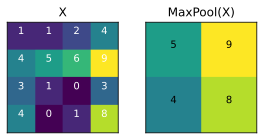

In [8]:
x = torch.tensor([
    [ 1, 1, 2, 4],
    [ 4, 5, 6, 9],
    [ 3, 1, 0, 3],
    [ 4, 0, 1, 8]]
)[None, None, :, :].float()

pool = nn.MaxPool2d(kernel_size=2, stride=2)

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(4, 2))
ax[0].set_title("X")
ax[0].imshow(x.numpy()[0, 0, :, :], cmap="viridis", vmin=0)
ax[0].set_xticks([])
ax[0].set_yticks([])
for i in range(4):
    for j in range(4):
        ax[0].text(j, i, int(x[0, 0, i, j].numpy()), ha="center", va="bottom", color="white")

ax[1].set_title("MaxPool(X)")
ax[1].imshow(pool(x)[0].detach().permute(1, 2, 0), cmap="viridis", vmin=0)
ax[1].set_xticks([])
ax[1].set_yticks([])
for i in range(2):
    for j in range(2):
        ax[1].text(j, i, int(pool(x)[0, 0, i, j].numpy()), ha="center", va="bottom", color="black")

fig.tight_layout()

Using a large kernel relative to the input can result in information loss:

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(6, 2))
ax[0].imshow(X[0, :, :, :].permute(1, 2, 0))
ax[0].set_title("Input", fontsize=9)
ax[1].imshow(nn.MaxPool2d(kernel_size=2, stride=2)(X)[0, :, :, :].permute(1, 2, 0))
ax[1].set_title("pool=2, stride=2", fontsize=9)
ax[2].imshow(nn.MaxPool2d(kernel_size=5, stride=3)(X)[0, :, :, :].permute(1, 2, 0))
ax[2].set_title("pool=5, stride=3", fontsize=9)
for i in range(3):
    ax[i].tick_params(axis="both", which="major", labelsize=8)

fig.tight_layout()
plt.savefig("./plots/03-maxpooling.svg", bbox_inches="tight")
plt.close("all")

:::{figure} ./plots/03-maxpooling.svg
---
name: 03-maxpooling
width: 100%
align: center
---
**Effect of max pooling.** Getting lower resolution images by increasing pooling size and stride.
:::



### Global pooling

Global pooling follows that intuition that we want to detect some patterns, but we do not care too much where exactly these patterns are ({numref}`03-pooling-text`). A **global average pooling** (GAP) layer will also be used later for an image classification task allowing the network to learn one feature detector for each output channel.

```{figure} ./img/03-pooling-text.png
---
width: 740px
name: 03-pooling-text
align: center
---

**Global pooling with text.**
A typical convolutional model for text consists of conv + pooling blocks. Here convolutions are applicable when we want to classify text using the presence of local features (e.g. certain phrases). [Source](https://lena-voita.github.io/nlp_course/models/convolutional.html)
```

## Convolutional Networks

In this section, we train an implementation of **LeNet-5** {cite:p}`lenet` on MNIST ({numref}`03-lenet`). 
LeNet-5 was used in the 1990s to identify handwritten zip code numbers in the US Postal Service ({numref}`03-lenet-timeline`).
This network is characterized as having convolution and pooling **blocks** as feature extractor. The features are then passed to an MLP with 10 output nodes for each class label.

**Remark.** A *block* is composed of multiple layers that together form a basic functional unit. This is generally used in designing neural net architectures. See also **AlexNet** {cite:p}`alexnet` and **VGG** {cite:p}`vgg` which take the CONV+POOL blocks design to the extreme ({numref}`03-alexnet-vgg`). AlexNet and VGG likewise contain consecutive convolutional blocks that downsample the spatial dims, while increasing the number of output channels so that network capacity is not diminished.
```{figure} ./img/03-alexnet-vgg.png
---
name: 03-alexnet-vgg
align: center
---
**Network architecture of AlexNet and VGG.** More layers means more processing, which is
why we see repeated convolutions and blocks. [Source](https://www.d2l.ai/chapter_convolutional-modern/vgg.html#vgg-network)
```
```{figure} ./img/03-lenet-timeline.png
---
name: 03-lenet-timeline
align: center
---
**A bit of history.** Timeline of the development of LeNet and MNIST. [Source](https://en.wikipedia.org/wiki/LeNet)
```

### Model

Combining convolution and pooling layers into a deep model:

In [13]:
import torchsummary

mnist_model = lambda: nn.Sequential(
    nn.Conv2d(1, 32, 3, 1, 1),
    nn.SELU(),
    nn.MaxPool2d(2, 2),
    
    nn.Conv2d(32, 32, 5, 1, 0),
    nn.SELU(),
    nn.MaxPool2d(2, 2),
    
    nn.Flatten(),
    nn.Linear(800, 256), nn.SELU(), nn.Dropout(0.5),
    nn.Linear(256, 10)
)

torchsummary.summary(mnist_model(), (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
              SELU-2           [-1, 32, 28, 28]               0
         MaxPool2d-3           [-1, 32, 14, 14]               0
            Conv2d-4           [-1, 32, 10, 10]          25,632
              SELU-5           [-1, 32, 10, 10]               0
         MaxPool2d-6             [-1, 32, 5, 5]               0
           Flatten-7                  [-1, 800]               0
            Linear-8                  [-1, 256]         205,056
              SELU-9                  [-1, 256]               0
          Dropout-10                  [-1, 256]               0
           Linear-11                   [-1, 10]           2,570
Total params: 233,578
Trainable params: 233,578
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/

**Remark.** For fun, we use **SELU activation** {cite:p}`selu` which is claimed to be self-normalizing. **Dropout** {cite:p}`dropout` is also used to regularize the dense layers. Observe that number of parameters due to convolutions is small relative to the final network size (only ~10%)!

Setting up MNIST data loaders:

In [14]:
from torchvision import transforms
from torchvision.datasets import MNIST
from torch.utils.data import random_split, DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x / 255.)
])

g = torch.Generator().manual_seed(RANDOM_SEED)
ds = MNIST(root=DATASET_DIR, download=False, transform=transform)
ds_train, ds_valid = random_split(ds, [55000, 5000], generator=g)
dl_train = DataLoader(ds_train, batch_size=32, shuffle=True)    # (!)
dl_valid = DataLoader(ds_valid, batch_size=32, shuffle=False)

**Remark.** `shuffle=True` is important for SGD training. The model will have low validation score when looping through the samples in the same order during training. This may be due to cyclic behavior in the updates (e.g. cancelling out).

### Trainer engine

To separate concerns during model training, we define a **trainer engine**. For example, this defines an `eval_context` to automatically set the model to eval mode at entry, and back to the default train mode at exit. This is useful for layers such as BN and Dropout which have different behaviors at train and test times. LR schedulers and callbacks are also implemented. Currently, these are called at the end of each training step (it is easy to extend this class to implement epoch end callbacks).

In [15]:
class eval_context:
    """Context manager to set model to eval mode."""
    def __init__(self, model):
        self.model = model
        self.state = model.training

    def __enter__(self):
        self.model.eval()

    def __exit__(self, exc_type, exc_value, traceback):
        self.model.train(self.state)


class Trainer:
    def __init__(self,
        model, optim, loss_fn, scheduler=None, callbacks=[],
        device=DEVICE, verbose=True
    ):
        self.model = model.to(device)
        self.optim = optim
        self.device = device
        self.loss_fn = loss_fn
        self.train_log = {"loss": [], "accs": [], "loss_avg": [], "accs_avg": []}
        self.valid_log = {"loss": [], "accs": []}
        self.verbose = verbose
        self.scheduler = scheduler
        self.callbacks = callbacks
    
    def __call__(self, x):
        return self.model(x.to(self.device))

    def forward(self, batch):
        x, y = batch
        x = x.to(self.device)
        y = y.to(self.device)
        return self.model(x), y

    def train_step(self, batch):
        preds, y = self.forward(batch)
        accs = (preds.argmax(dim=1) == y).float().mean()
        loss = self.loss_fn(preds, y)
        loss.backward()
        self.optim.step()
        self.optim.zero_grad()
        return {"loss": loss, "accs": accs}

    @torch.inference_mode()
    def valid_step(self, batch):
        with eval_context(self.model):
            preds, y = self.forward(batch)
            accs = (preds.argmax(dim=1) == y).float().sum()
            loss = self.loss_fn(preds, y, reduction="sum")
        return {"loss": loss, "accs": accs}
    
    def run(self, epochs, train_loader, valid_loader):
        for e in tqdm(range(epochs)):
            for batch in train_loader:
                # optim and lr step
                output = self.train_step(batch)
                if self.scheduler:
                    self.scheduler.step()

                # step callbacks
                for callback in self.callbacks:
                    callback()

                # logs @ train step
                steps_per_epoch = len(train_loader)
                w = int(0.05 * steps_per_epoch)
                self.train_log["loss"].append(output["loss"].item())
                self.train_log["accs"].append(output["accs"].item())
                self.train_log["loss_avg"].append(np.mean(self.train_log["loss"][-w:]))
                self.train_log["accs_avg"].append(np.mean(self.train_log["accs"][-w:]))

            # logs @ epoch
            output = self.evaluate(valid_loader)
            self.valid_log["loss"].append(output["loss"])
            self.valid_log["accs"].append(output["accs"])
            if self.verbose:
                print(f"[Epoch: {e+1:>0{int(len(str(epochs)))}d}/{epochs}]    loss: {self.train_log['loss_avg'][-1]:.4f}  acc: {self.train_log['accs_avg'][-1]:.4f}    val_loss: {self.valid_log['loss'][-1]:.4f}  val_acc: {self.valid_log['accs'][-1]:.4f}")

    def evaluate(self, data_loader):        
        valid_loss = 0.0
        valid_accs = 0.0
        for batch in data_loader:
            output = self.valid_step(batch)
            valid_loss += output["loss"].item()
            valid_accs += output["accs"].item()

        return {
            "loss": valid_loss / len(data_loader.dataset),
            "accs": valid_accs / len(data_loader.dataset)
        }

    @torch.inference_mode()
    def predict(self, x: torch.Tensor):
        with eval_context(self.model):
            return self(x)

The `predict` method is suited for inference over one *transformed* mini-batch. The model does not generate a computational graph to conserve memory and calls the model with layers in eval mode. For large batches, spread out inference to avoid OOM  (⚠), e.g. by iterating over a data loader with transforms.

In [16]:
model = nn.Sequential(nn.Linear(3, 10), nn.Dropout(1.0))
trainer = Trainer(model, optim=None, scheduler=None, loss_fn=None)

# inference mode using eval_context
x = torch.ones(size=(1, 3), requires_grad=True)
print(f"__call__    {(trainer(x) > 0).float().mean():.3f}")
print(f"predict     {(trainer.predict(x) > 0).float().mean():.3f}")

__call__    0.000
predict     0.600


Checking computational graph generation:

In [17]:
y = trainer(x)
z = trainer.predict(x)
print("__call__   ", y.requires_grad)
print("predict    ", z.requires_grad)

__call__    True
predict     False


### LR scheduling

Training the model with [one-cycle LR schedule](https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.OneCycleLR.html) {cite:p}`super-convergence-resnet`. This policy anneals the learning rate from a base LR to a set maximum LR, and then, to a minimum LR much lower than the base LR. Momentum may also be annealed inversely to the learning rate for the sake of stability (`cycle_momentum` which defaults to `True`).

In [18]:
from torch.optim.lr_scheduler import OneCycleLR

class SchedulerStatsCallback:
    def __init__(self, optim):
        self.lr = []
        self.momentum = []
        self.optim = optim

    def __call__(self):
        self.lr.append(self.optim.param_groups[0]["lr"])
        self.momentum.append(self.optim.param_groups[0]["betas"][0])

epochs = 4
model = mnist_model().to(DEVICE)
loss_fn = F.cross_entropy
optim = torch.optim.AdamW(model.parameters(), lr=0.001)
scheduler = OneCycleLR(optim, max_lr=0.01, steps_per_epoch=len(dl_train), epochs=epochs, cycle_momentum=True)
scheduler_stats = SchedulerStatsCallback(optim)
trainer = Trainer(model, optim, loss_fn, scheduler, callbacks=[scheduler_stats])

Training:

In [19]:
trainer.run(epochs=epochs, train_loader=dl_train, valid_loader=dl_valid)

100%|██████████| 4/4 [01:20<00:00, 20.16s/it]



[Epoch: 1/4]    loss: 1.3339  acc: 0.8824    val_loss: 0.9359  val_acc: 0.8944
[Epoch: 2/4]    loss: 0.6691  acc: 0.9268    val_loss: 0.2706  val_acc: 0.9672
[Epoch: 3/4]    loss: 0.2790  acc: 0.9594    val_loss: 0.1236  val_acc: 0.9764
[Epoch: 4/4]    loss: 0.1522  acc: 0.9701    val_loss: 0.0858  val_acc: 0.9840


In [20]:
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(8, 4), gridspec_kw={'height_ratios': [4, 1]})

AX1_COLOR = "C0"
AX2_COLOR = "C1"
ax1.plot(trainer.train_log["loss"], color=AX1_COLOR, linewidth=1, alpha=0.6)
ax1.plot(trainer.train_log["loss_avg"], color=AX1_COLOR, linewidth=2)
ax1.grid(axis="both", linestyle="dotted", alpha=0.8)
ax1.set_xlabel("step")

ax2 = ax1.twinx()
ax2.plot(trainer.train_log["accs"], color=AX2_COLOR, linewidth=1, alpha=0.6)
ax2.plot(trainer.train_log["accs_avg"], color=AX2_COLOR, linewidth=2)

ax1.set_ylabel("Train loss")
ax2.set_ylabel("Train accuracy (%)")
ax1.yaxis.label.set_color(AX1_COLOR)
ax2.yaxis.label.set_color(AX2_COLOR)

ax4 = ax3.twinx()
ax3.plot(scheduler_stats.lr, color="black", label="lr", linewidth=2)
ax4.plot(scheduler_stats.momentum, color="blue", label=r"$\beta_1$", linewidth=2)
ax4.grid(linestyle="dotted")
ax3.set_xlabel("step")
ax3.set_ylabel("lr")
ax4.set_ylabel(r"$\beta_1$")
ax3.yaxis.label.set_color("black")
ax4.yaxis.label.set_color("blue")

fig.tight_layout()
plt.savefig("./plots/03-training-lrs.svg", bbox_inches="tight")
plt.close("all")

:::{figure} ./plots/03-training-lrs.svg
---
name: 03-training-lrs
width: 100%
align: center
---
**Figure.** Note peak in train loss as LR increases to `max_lr` set at initialization, and the decreasing noise as the LR decreases at the end of training.
This works similar [our previous LR finder](http://localhost:3000/optim#learning-rate) which is a parameter-free method for finding a good base `lr`.
:::


**Remarks.** (1) After trying out other activations... SELU performance @ 98+% `val_acc` is surprising. It also trains really fast. That self-normalizing bit is no joke! (2) Bump in LR ({numref}`03-training-lrs`) occurs over a wide duration during training, 
it may have allowed the optimizer to avoid many sharp minima. 
This allows the network to train with less epochs[^epoch1cycle]. 

[^epoch1cycle]: On the other hand, increasing the number of 
epochsscales up the exploration time, along with convergence time! Epoch count with one-cycle LR can be thought of as affecting granularity of the training process, instead of just more optimizer steps.

In [22]:
torch.save(model.state_dict(), ARTIFACTS_DIR / "mnist_model.pkl")

### Feature maps

Showing intermediate activations during training (i.e. Dropout = ON). Recall that feature map in the input of a convolutional layer is used to create each output feature map. Max-pooling and SELU on the other hand acts on each feature map independently. Note that fully-connected layer outputs are reshaped to two dimensions for the sake of presentation.

In [24]:
from matplotlib.colors import LinearSegmentedColormap

x, y = next(iter(dl_valid))
b = torch.argmax((y == 8).type(torch.int64))
x = x[b:b+1, :].to(DEVICE) # first element

width_ratios = [1, 0.2, 1, 1, 1, 0.2, 1, 1, 1, 0.2, 0.6, 0.6, 0.6, 0.6, 0.8]
fig = plt.figure(figsize=(12, 5), constrained_layout=True)
spec = fig.add_gridspec(5, len(width_ratios), width_ratios=width_ratios)
cmap = LinearSegmentedColormap.from_list("custom", ["red", "white", "blue"])

# Input image
input_layer = []
for i in range(5):
    input_layer.append(fig.add_subplot(spec[i, 0]))
    input_layer[i].set_axis_off()

input_layer[2].imshow(x[0, 0].cpu().detach().numpy(), cmap="Greys")
input_layer[0].set_title("Input")

# Block 1
for k in range(3):
    x = model[k](x)
    layer = []
    for i in range(5):
        layer.append(fig.add_subplot(spec[i, k + 2]))
        layer[i].set_axis_off()
        layer[i].imshow(x[0, i+10].cpu().detach().numpy(), cmap="Greys")
        layer[i].axis("off")
    layer[0].set_title(type(model[k]).__name__)

# Block 2
for k in range(3):
    x = model[3 + k](x)
    layer = []
    for i in range(5):
        layer.append(fig.add_subplot(spec[i, k + 6]))
        layer[i].set_axis_off()
        layer[i].imshow(x[0, i].cpu().detach().numpy())
        layer[i].axis("off")
    layer[0].set_title(type(model[k]).__name__)

# Classification subnetwork
for l in range(5):
    x = model[6 + l](x)
    if l == 0:
        data = x[0].cpu().detach().view(-1, 8).numpy()
    elif l < 4:
        data = x[0].cpu().detach().view(-1, 4).numpy()
    else:
        data = x[0].cpu().detach().view(-1, 1).numpy()

    a = np.abs(data).max()
    ax = fig.add_subplot(spec[:, 10 + l])
    ax.imshow(data, cmap=cmap, vmin=-a, vmax=a)
    ax.xaxis.set_visible(False)
    ax.set_title(type(model[6 + l]).__name__)
    ax.tick_params(axis="y", colors="white")


# For last layer annotate value
for i in range(10):
    ax.tick_params(axis="y", colors="black")
    ax.set_yticks(range(10))
    ax.text(0, i, f"{data[i, 0]:.1f}", ha="center", va="center", color="black")
    
fig.tight_layout(pad=0.00)
plt.savefig("./plots/03-mnist_feature_maps.svg", bbox_inches="tight")
plt.close("all")


:::{figure} ./plots/03-mnist_feature_maps.svg
---
name: 03-mnist_feature_maps
width: 100%
align: center
---
**Feature maps of MNIST instance as it passes through network layers.** Only 4 output channels are shown due to space limitation. The features become more abstract deeper into the network. Finally, we get a score distribution at the end.
:::

---